# 1D Peak Finding via Density Slices & Savitzky-Golay Filtering

This approach identifies peaks in the 1D histogram ("spectrogram") of the data for each week.
* **SST**: Extracts the top 2 peaks. If only 1 peak is found, we assume the two curves overlap and duplicate that peak for both curves. Then, we apply a Savitzky-Golay filter to smooth and bridge the curves.
* **SSL**: Extracts up to 3 peaks. We don't assume overlap, so found peaks are matched to their closest approximate band. Then, we interpolate any missing gaps entirely and apply Savitzky-Golay filtering.

In [27]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import gaussian_filter1d
import warnings
from tqdm.auto import tqdm

plt.style.use('default')

In [28]:
# 1. Load the data
file_path = r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl'
try:
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    df = data['data']
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Data file not found. Please check path.")

# Extract just SST and SSL
years_to_process = [2018] # Change this to a list of years like list(range(2010, 2020)) to process multiple years, or None for all

if years_to_process is not None:
    df_all_years = df[df.index.year.isin(years_to_process)].copy()
else:
    df_all_years = df.copy()

df_all_years['week'] = df_all_years.index.isocalendar().week

products = ['sst', 'ssl']
weekly_data = {p: [] for p in products}

for week_num, week_df in tqdm(df_all_years.groupby('week'), desc="Processing weeks"):
    for p in products:
        grids = []
        for _, row in week_df.iterrows():
            grid = row.get(p)
            if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
                grid_arr = np.array(grid, dtype=float)
                if not np.isnan(grid_arr).all():
                    grids.append(grid_arr)
        
        if grids:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', category=RuntimeWarning)
                avg_grid = np.nanmean(np.stack(grids), axis=0)
                values = avg_grid.flatten()
                values = values[~np.isnan(values)]
                
                if len(values) > 0:
                    for val in values:
                        weekly_data[p].append({'week': week_num, 'value': val})

for p in products:
    weekly_data[p] = pd.DataFrame(weekly_data[p])

Data loaded successfully.


Processing weeks:   0%|          | 0/52 [00:00<?, ?it/s]

In [29]:
# Function to create the density map (2D Histogram)
def get_density_map(df_p, y_bins_count=100):
    x_bins = np.arange(1, 54) - 0.5
    range_y = [df_p['value'].min(), df_p['value'].max()]
    
    h, xedges, yedges = np.histogram2d(
        df_p['week'], df_p['value'],
        bins=[x_bins, y_bins_count],
        range=[[0.5, 52.5], range_y]
    )
    
    # Store bin centers for plotting/fitting
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    
    return h, x_centers, y_centers

## SST: Peak Identification + Overlap Logic + Savitzky-Golay
Extract 1D columns for each week. Find peaks and smooth them.

In [30]:
df_sst = weekly_data['sst']
h_sst, x_sst, y_sst = get_density_map(df_sst, y_bins_count=100)

c1, c2 = [], []

for i in range(h_sst.shape[0]):
    # Smooth the 1D slice slightly to prevent multi-peak noise
    slice_1d = gaussian_filter1d(h_sst[i, :], sigma=2)
    # Extract peaks
    peaks, _ = find_peaks(slice_1d, prominence=np.max(slice_1d)*0.05)
    
    # Sort peaks by highest prominence/density inside the slice
    peaks = sorted(peaks, key=lambda p: slice_1d[p], reverse=True)
    
    if len(peaks) >= 2:
        top_2 = sorted(peaks[:2]) # Sort by Y-value to separate top vs bottom curve
        c1.append(y_sst[top_2[0]])  # Lower curve
        c2.append(y_sst[top_2[1]])  # Upper curve
    elif len(peaks) == 1:
        # Assume curves overlap at this single robust peak
        c1.append(y_sst[peaks[0]])
        c2.append(y_sst[peaks[0]])
    else:
        # No peak found, just put NaN
        c1.append(np.nan)
        c2.append(np.nan)

# Interpolate NaNs if any missed slices exist
c1_interp = pd.Series(c1).interpolate(limit_direction='both').values
c2_interp = pd.Series(c2).interpolate(limit_direction='both').values

# Apply Savitzky-Golay for smoothing curves globally
window_len = 11  # Must be odd
poly_ord = 2
c1_smooth = savgol_filter(c1_interp, window_length=window_len, polyorder=poly_ord)
c2_smooth = savgol_filter(c2_interp, window_length=window_len, polyorder=poly_ord)

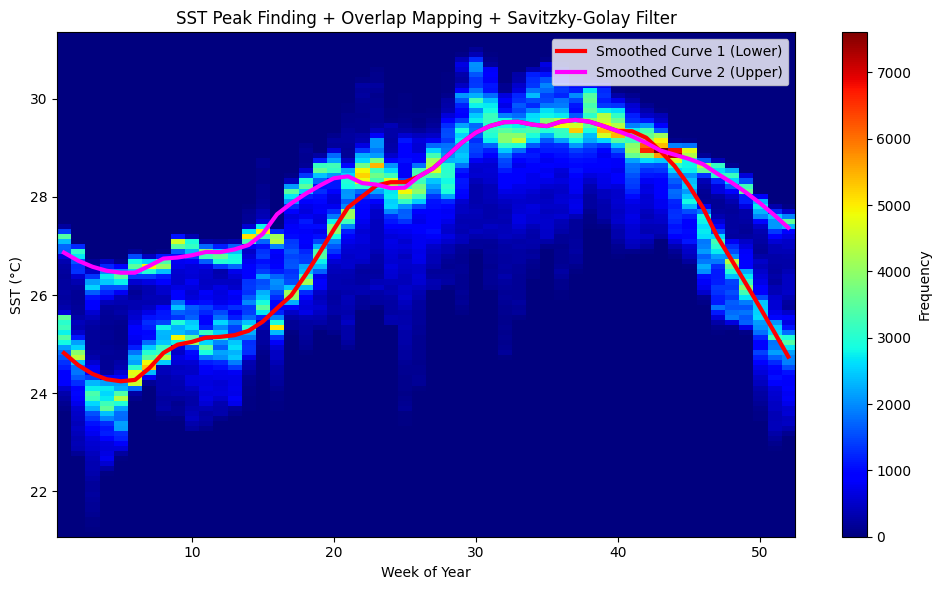

In [31]:
plt.figure(figsize=(10, 6))
plt.imshow(h_sst.T, origin='lower', aspect='auto', 
           extent=[0.5, 52.5, y_sst.min(), y_sst.max()], 
           cmap='jet')
plt.colorbar(label='Frequency')

plt.plot(x_sst, c1_smooth, color='red', lw=3, label='Smoothed Curve 1 (Lower)')
plt.plot(x_sst, c2_smooth, color='magenta', lw=3, label='Smoothed Curve 2 (Upper)')

plt.title("SST Peak Finding + Overlap Mapping + Savitzky-Golay Filter")
plt.xlabel("Week of Year")
plt.ylabel("SST (°C)")
plt.legend()
plt.tight_layout()
plt.show()

## SSL: Peak Identification + Strict Band Matching + Savitzky-Golay
For SSL, we have 3 independent bands and we do not assume overlap. We assign found peaks spatially to the Bottom, Mid, and Top bands.

In [32]:
df_ssl = weekly_data['ssl']
h_ssl, x_ssl, y_ssl = get_density_map(df_ssl, y_bins_count=150)

ssl1, ssl2, ssl3 = [], [], []
bands_approx = [0.25, 0.45, 0.65] # Rough initialization for Bottom, Mid, Top SSL distributions

for i in range(h_ssl.shape[0]):
    slice_1d = gaussian_filter1d(h_ssl[i, :], sigma=2)
    peaks, _ = find_peaks(slice_1d, prominence=np.max(slice_1d)*0.02)
    peaks = sorted(peaks, key=lambda p: slice_1d[p], reverse=True)
    
    v1, v2, v3 = np.nan, np.nan, np.nan
    
    # Assign up to 3 highest peaks to their closest theoretical band, no overlap duplication
    for p in peaks[:3]:
        val = y_ssl[p]
        distances = [abs(val - b) for b in bands_approx]
        best_match = np.argmin(distances)
        
        # Fill available slots without overriding an already assigned peak
        if best_match == 0 and np.isnan(v1): v1 = val
        elif best_match == 1 and np.isnan(v2): v2 = val
        elif best_match == 2 and np.isnan(v3): v3 = val
        elif np.isnan(v1): v1 = val
        elif np.isnan(v2): v2 = val
        elif np.isnan(v3): v3 = val
        
    ssl1.append(v1)
    ssl2.append(v2)
    ssl3.append(v3)

# Interpolate the non-overlapping NaN gaps entirely
ssl1_interp = pd.Series(ssl1).interpolate(limit_direction='both').values
ssl2_interp = pd.Series(ssl2).interpolate(limit_direction='both').values
ssl3_interp = pd.Series(ssl3).interpolate(limit_direction='both').values

# Apply Savitzky-Golay for smoothing curves globally
ssl1_smooth = savgol_filter(ssl1_interp, window_length=11, polyorder=2)
ssl2_smooth = savgol_filter(ssl2_interp, window_length=11, polyorder=2)
ssl3_smooth = savgol_filter(ssl3_interp, window_length=11, polyorder=2)

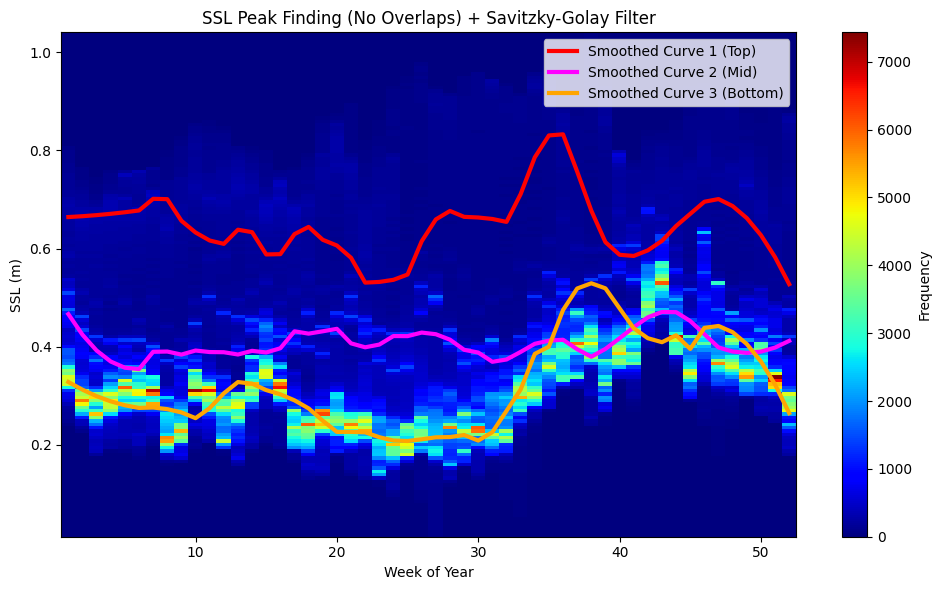

In [33]:
plt.figure(figsize=(10, 6))
plt.imshow(h_ssl.T, origin='lower', aspect='auto', 
           extent=[0.5, 52.5, y_ssl.min(), y_ssl.max()], 
           cmap='jet')
plt.colorbar(label='Frequency')

plt.plot(x_ssl, ssl3_smooth, color='red', lw=3, label='Smoothed Curve 1 (Top)')
plt.plot(x_ssl, ssl2_smooth, color='magenta', lw=3, label='Smoothed Curve 2 (Mid)')
plt.plot(x_ssl, ssl1_smooth, color='orange', lw=3, label='Smoothed Curve 3 (Bottom)')

plt.title("SSL Peak Finding (No Overlaps) + Savitzky-Golay Filter")
plt.xlabel("Week of Year")
plt.ylabel("SSL (m)")
plt.legend()
plt.tight_layout()
plt.show()

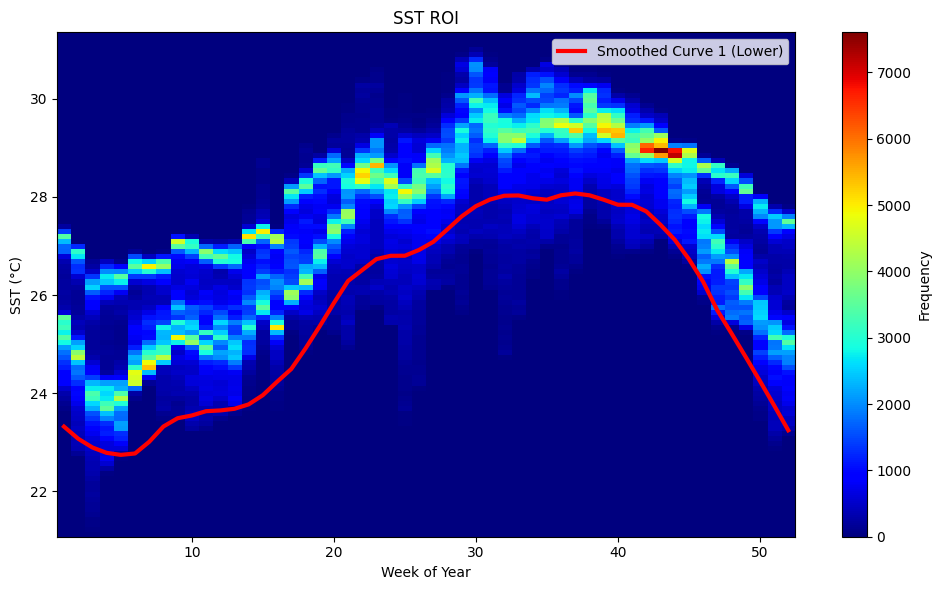

In [44]:
threshold_val = -1.5

plt.figure(figsize=(10, 6))
plt.imshow(h_sst.T, origin='lower', aspect='auto', 
           extent=[0.5, 52.5, y_sst.min(), y_sst.max()], 
           cmap='jet')
plt.colorbar(label='Frequency')

plt.plot(x_sst, c1_smooth + threshold_val, color='red', lw=3, label='Smoothed Curve 1 (Lower)')

plt.title("SST ROI")
plt.xlabel("Week of Year")
plt.ylabel("SST (°C)")
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
import warnings

# Create directory for videos
os.makedirs('videos', exist_ok=True)

# 1. Filter data for 2018
# Assuming df has a DatetimeIndex
df_2018 = df.loc['2018'].copy()

# 2. Interpolate the weekly curves (c1_smooth, c2_smooth) to daily values (Day of Year)
# There are 52 weeks in the generated curves, we interpret them evenly spaced across 365 days
week_centers = np.linspace(1, 365, len(c1_smooth))
daily_c1 = np.interp(np.arange(1, 367), week_centers, c1_smooth)
daily_c2 = np.interp(np.arange(1, 367), week_centers, c2_smooth)

daily_groups = df_2018.groupby(df_2018.index.date)

dates = []
grids = []

print("Processing daily grids for 2018...")
for date, group in daily_groups:
    doy = date.timetuple().tm_yday
    c1_val = daily_c1[doy - 1]
    
    # Get mean grid for the day (handling multiple passes if any exist)
    day_grids = []
    for _, row in group.iterrows():
        grid = row.get('sst')
        if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
            day_grids.append(np.array(grid, dtype=float))
            
    if not day_grids:
        continue
        
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        sst_grid = np.nanmean(np.stack(day_grids), axis=0)
    
    # Segment the grid: Binary Map
    # Target: [lowest point -> 1 celsius below the lower curve of the SST]
    seg_grid = np.zeros_like(sst_grid)
    target_mask = sst_grid <= (c1_val + threshold_val)
    seg_grid[target_mask] = 1
    
    # Preserve NaNs to avoid plotting land/missing data as a valid category
    seg_grid[np.isnan(sst_grid)] = np.nan
        
    dates.append(date)
    grids.append(seg_grid)

# 3. Create Video Animation
print(f"Generating video with {len(grids)} frames...")
fig, ax = plt.subplots(figsize=(8, 6))

# Binary map colors: Other=Blue, Target=Red
cmap = mcolors.ListedColormap(['blue', 'red'])
cmap.set_bad('grey') # Color for NaNs (land/missing)
bounds = [-0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Initialize plot with the first valid grid
# Added origin='lower' to flip the map so North is up
cax = ax.imshow(grids[0] if grids else np.zeros((10,10)), cmap=cmap, norm=norm, origin='lower', animated=True)
cbar = fig.colorbar(cax, ax=ax, ticks=[0, 1])
cbar.ax.set_yticklabels(['Other', 'Target (\u2264 C1 + threshold)'])

title = ax.set_title('')

def update(frame_idx):
    cax.set_array(grids[frame_idx])
    doy = dates[frame_idx].timetuple().tm_yday
    title.set_text(f'SST Segmentation - {dates[frame_idx]}\nTarget threshold: \u2264 {daily_c1[doy-1] + threshold_val:.2f}\u00b0C (C1: {daily_c1[doy-1]:.2f}\u00b0C)')
    return cax, title

if grids:
    ani = FuncAnimation(fig, update, frames=len(grids), blit=False)
    video_path = 'videos/sst_segmentation_2018.mp4'
    
    try:
        # Requires ffmpeg installed or a suitable writer
        ani.save(video_path, fps=10, writer='ffmpeg')
        print(f"Video successfully saved to {video_path}")
    except RuntimeError as e:
        print("Could not save mp4 via ffmpeg. Attempting fallback to save via pillow as a GIF...")
        gif_path = video_path.replace('.mp4', '.gif')
        ani.save(gif_path, fps=10, writer='pillow')
        print(f"Video saved as GIF instead at {gif_path}")
plt.close()

Processing daily grids for 2018...
Generating video with 365 frames...
Video successfully saved to videos/sst_segmentation_2018.mp4
